## EDA and Data Loading

In [14]:
import pandas as pd
import numpy as np
# %pip install kagglehub
import kagglehub



path = kagglehub.dataset_download("andrewmvd/early-diabetes-classification")
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load directly into DataFrame
df = pd.read_csv(f"{path}/diabetes_data.csv", sep=';')
df.head()

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
0,40,Male,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,Male,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,Male,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,Male,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,Male,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


In [15]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})  # Encoding Gender
X_pima = df.drop('class', axis=1)
y_pima = df['class'] # Already 0 and 1, no mapping needed

print(f"Target Values: {y_pima.unique()}")
print(f"Data Shape: {X_pima.shape}")

# --- UNCOMMENT BELOW TO USE THIS DATASET INSTEAD ---
X = X_pima
y = y_pima.rename('diagnosis') # Renaming 
target_names = np.array(['No Diabetes', 'Diabetes'])
df = pd.concat([X, y], axis=1)


Target Values: [1 0]
Data Shape: (520, 16)


In [16]:
#observing head
df.head()

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,diagnosis
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


In [17]:
# checking for missing values, shape and data types
print("---DataFrame Shape---", df.shape)
print("\n---Data Types---\n", df.dtypes)
print("\n---Missing Values---\n", df.isnull().sum())
print("\n--unique values in each column--")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

---DataFrame Shape--- (520, 17)

---Data Types---
 age                   int64
gender                int64
polyuria              int64
polydipsia            int64
sudden_weight_loss    int64
weakness              int64
polyphagia            int64
genital_thrush        int64
visual_blurring       int64
itching               int64
irritability          int64
delayed_healing       int64
partial_paresis       int64
muscle_stiffness      int64
alopecia              int64
obesity               int64
diagnosis             int64
dtype: object

---Missing Values---
 age                   0
gender                0
polyuria              0
polydipsia            0
sudden_weight_loss    0
weakness              0
polyphagia            0
genital_thrush        0
visual_blurring       0
itching               0
irritability          0
delayed_healing       0
partial_paresis       0
muscle_stiffness      0
alopecia              0
obesity               0
diagnosis             0
dtype: int64

--unique value

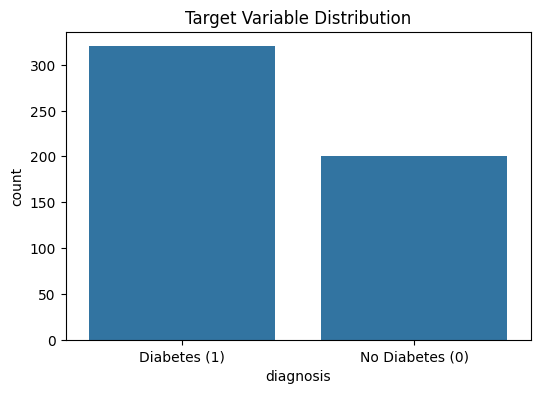

diagnosis
1    0.615385
0    0.384615
Name: proportion, dtype: float64


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# checking if the classes are balanced
plt.figure(figsize=(6, 4))
sns.countplot(x=y.map({0: 'No Diabetes (0)', 1: 'Diabetes (1)'}))
plt.title('Target Variable Distribution')
plt.show()

print(y.value_counts(normalize=True))

## Data Preprocessing

We'll create a `Pipeline` that first scales the data using `StandardScaler` and then runs the model.

From there, we will create pipelines for our models, build, train, and get baseline results.



X_train shape: (364, 16)
X_test shape: (156, 16)
y_train shape: (364,)
y_test shape: (156,)
After SMOTE (train) counts of label '1': 224
After SMOTE (train) counts of label '0': 224 



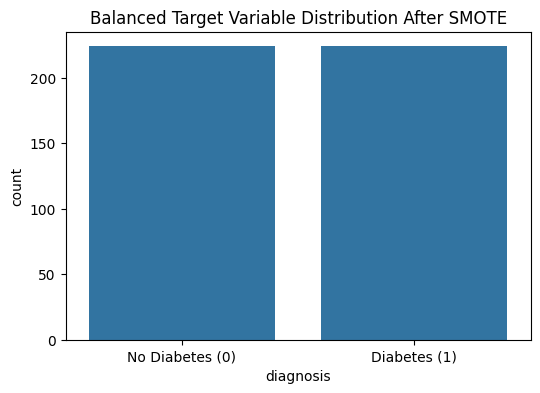

In [19]:
from sklearn.model_selection import train_test_split

# we are doing a 70/30 split of the data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# %pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE (train) counts of label '1': {}".format(sum(y_train_res==1)))
print("After SMOTE (train) counts of label '0': {} \n".format(sum(y_train_res==0)))

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_res.map({0: 'No Diabetes (0)', 1: 'Diabetes (1)'}))
plt.title('Balanced Target Variable Distribution After SMOTE')
plt.show()

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler

,copy,True
,with_mean,True
,with_std,True


## Model Implementation

--- Univariate Logistic AUC (using SMOTE resampled train) ---
               Feature       AUC
2             polyuria  0.841518
3           polydipsia  0.837054
4   sudden_weight_loss  0.745536
1               gender  0.727679
12     partial_paresis  0.718750
6           polyphagia  0.671875
5             weakness  0.633929
14            alopecia  0.631696
10        irritability  0.613839
8      visual_blurring  0.613839
0                  age  0.564961
7       genital_thrush  0.558036
15             obesity  0.537946
13    muscle_stiffness  0.529018
11     delayed_healing  0.515625
9              itching  0.500000


C:\Users\edgar\AppData\Local\Temp\ipykernel_24424\3913511878.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AUC', y='Feature', data=auc_df, palette='viridis')


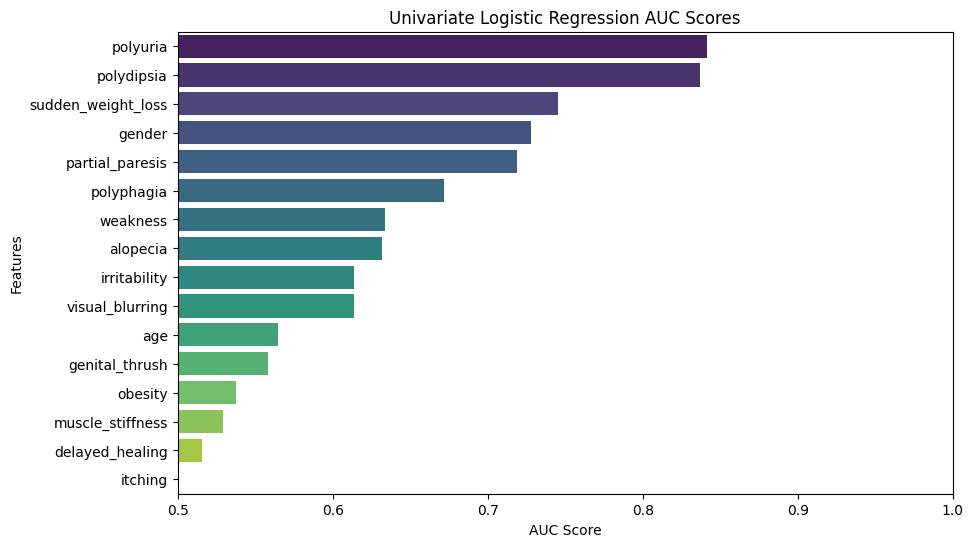

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

auc_results = []
print("--- Univariate Logistic AUC (using SMOTE resampled train) ---")
for feature in X_train_res.columns:
    lr = LogisticRegression(solver='liblinear')
    X_feat = X_train_res[[feature]]
    lr.fit(X_feat, y_train_res)
    proba = lr.predict_proba(X_feat)[:, 1]
    auc = roc_auc_score(y_train_res, proba)
    auc_results.append({'Feature': feature, 'AUC': auc})

auc_df = pd.DataFrame(auc_results).sort_values(by='AUC', ascending=False)
print(auc_df)

# plotting the auc
plt.figure(figsize=(10, 6))
sns.barplot(x='AUC', y='Feature', data=auc_df, palette='viridis')
plt.title('Univariate Logistic Regression AUC Scores')
plt.xlabel('AUC Score')
plt.ylabel('Features')
plt.xlim(0.5, 1)
plt.show()

### K-NN

We have previously implemented the same GLM, SVM, and SVM RBF models on similar data.

According to "Data-Driven Machine-Learning Methods for Diabetes Risk Prediction" by Elias DritsasORCID and Maria Trigka, a variety of models were tested on a different diabetes dataset.
In this file, we implement the same models to evaluate performance on binary data and evaluate their performance, as well as integrate new  models that could perhaps perform better.

### Logistic Regression

Creating a pipeling for logistic regression, train the model and evaluate

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, solver= 'liblinear'))
])

# training
lr_pipeline.fit(X_train_res, y_train_res)

# get predictions on the test set
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# calculating metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print("--- Logistic Regression Test Results ---")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"AUC: {auc_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=target_names))


--- Logistic Regression Test Results ---
Accuracy: 0.9231
AUC: 0.9700

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.85      0.97      0.91        60
    Diabetes       0.98      0.90      0.93        96

    accuracy                           0.92       156
   macro avg       0.92      0.93      0.92       156
weighted avg       0.93      0.92      0.92       156



### GLM Analysis

1. Overall Performance (Decent Baseline)

Accuracy (74.5%): The model correctly classifies about 3 out of 4 patients. This is a standard baseline for the Pima Indians dataset, which is known to be difficult due to the high overlap in features like BMI and Age.
AUC (0.84): The Area Under the Curve is strong (0.84), significantly higher than the accuracy. This indicates the model is actually quite good at distinguishing between the two classes in terms of probability, even if the final hard predictions aren't perfect.

2. The Critical Weakness: Missing Positive Cases

Diabetes Recall (Sensitivity) is Low (0.52): This is the most concerning metric. The model only identified 52% of the people who actually have diabetes.
High False Negatives: It missed nearly half (48%) of the positive cases. In a medical screening context, this is risky because many sick patients would be told they are healthy.

3. Class Imbalance Effect

The model is much better at predicting "No Diabetes" (Recall 0.87) than "Diabetes". It has learned to be conservative, preferring to predict "Healthy" unless the evidence is very strong.

**Conclusion:**

While the model has good discriminative power (high AUC), the default decision threshold makes it too conservative.

### SVM

We will create a pipeline for linear SVM, train, and evaluate the model

In [39]:
from sklearn.svm import SVC

svm_linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # using a new instance of scaler
    ('svm_linear', SVC(kernel='linear', probability=True, random_state=42))
])

# training the model
svm_linear_pipeline.fit(X_train_res, y_train_res)

# evaluating the linear svm and checking performance agains the logisitic regression model
y_pred_svm_linear = svm_linear_pipeline.predict(X_test)
y_proba_svm_linear = svm_linear_pipeline.predict_proba(X_test)[:, 1]

# calculating metrics
accuracy_svm_linear = accuracy_score(y_test, y_pred_svm_linear)
auc_svm_linear = roc_auc_score(y_test, y_proba_svm_linear)

print("--- Linear SVM Test Results ---")
print(f"Accuracy: {accuracy_svm_linear:.4f}")
print(f"AUC: {auc_svm_linear:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_linear, target_names=target_names))


--- Linear SVM Test Results ---
Accuracy: 0.9295
AUC: 0.9687

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.87      0.97      0.91        60
    Diabetes       0.98      0.91      0.94        96

    accuracy                           0.93       156
   macro avg       0.92      0.94      0.93       156
weighted avg       0.93      0.93      0.93       156



### Linear SVM Analysis

1. **Overall Performance (Slightly Worse than Baseline)**
   - **Accuracy (72.73%)**: The accuracy dropped slightly compared to Logistic Regression (74.46%). It remains a reasonable baseline but is outperformed by the simpler model.
   - **AUC (0.8333)**: The AUC is very similar to Logistic Regression (0.8380), indicating that the model's ability to rank patients by risk is comparable, even if the specific decision boundary is less optimal.

2. **The Critical Weakness: Low Sensitivity**
   - **Diabetes Recall (0.49)**: This is the most concerning metric. The Linear SVM correctly identified only **49%** of the positive diabetes cases.
   - **Comparison**: It missed more cases than Logistic Regression (which had a recall of 0.52). In a medical screening context, missing 51% of positive cases makes this model ineffective without threshold adjustment.

3. **Conclusion**
   - The Linear SVM offers no advantage over Logistic Regression for this specific dataset split. It delivers slightly worse results across Accuracy, Precision, and Recall while being computationally more intensive.

### Non-Linear Kernel (RBF)
Implementing a Non-linear kernel (RBF) and using GridSearchCV to find the best ```C``` and ```gamma``` parameters.

In [44]:
from sklearn.model_selection import GridSearchCV

# creating a pipeline for RBF SVM
svm_rbf_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # using a new instance of scaler
    ('svm_rbf', SVC(kernel='rbf', probability=True, random_state=42))
])

# defining parameter grid for GridSearchCV
param_grid = {
    'svm_rbf__C': [0.1, 1, 10],
    'svm_rbf__gamma': [1, 0.1, 0.01, 0.001, 1.5]
}

# setting up GridSearchCV to find the best parameters using 5-fold cross-validation
svm_grid = GridSearchCV(svm_rbf_pipeline, param_grid, refit=True, verbose=2, cv=5, scoring='roc_auc')

# train the model (gridsearchcv will find the best model parameters and retrain it on all training data)
svm_grid.fit(X_train_res, y_train_res)
print(f"Best Parameters from GridSearchCV: {svm_grid.best_params_}")


Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV] END ...................svm_rbf__C=0.1, svm_rbf__gamma=1; total time=   0.0s
[CV] END ...................svm_rbf__C=0.1, svm_rbf__gamma=1; total time=   0.0s
[CV] END ...................svm_rbf__C=0.1, svm_rbf__gamma=1; total time=   0.0s
[CV] END ...................svm_rbf__C=0.1, svm_rbf__gamma=1; total time=   0.0s
[CV] END ...................svm_rbf__C=0.1, svm_rbf__gamma=1; total time=   0.0s
[CV] END .................svm_rbf__C=0.1, svm_rbf__gamma=0.1; total time=   0.0s
[CV] END .................svm_rbf__C=0.1, svm_rbf__gamma=0.1; total time=   0.0s
[CV] END .................svm_rbf__C=0.1, svm_rbf__gamma=0.1; total time=   0.0s
[CV] END .................svm_rbf__C=0.1, svm_rbf__gamma=0.1; total time=   0.0s
[CV] END .................svm_rbf__C=0.1, svm_rbf__gamma=0.1; total time=   0.0s
[CV] END ................svm_rbf__C=0.1, svm_rbf__gamma=0.01; total time=   0.0s
[CV] END ................svm_rbf__C=0.1, svm_rbf

In [46]:
# Now w will make predictions and evaluate the model
y_pred_svm_rbf = svm_grid.predict(X_test)
y_proba_svm_rbf = svm_grid.predict_proba(X_test)[:, 1]

# calculating metrics
accuracy_svm_rbf = accuracy_score(y_test, y_pred_svm_rbf)
auc_svm_rbf = roc_auc_score(y_test, y_proba_svm_rbf)

print("--- RBF SVM Test Results ---")
print(f"Accuracy: {accuracy_svm_rbf:.4f}")
print(f"AUC: {auc_svm_rbf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_rbf, target_names=target_names))

--- RBF SVM Test Results ---
Accuracy: 0.9551
AUC: 0.9991

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       1.00      0.88      0.94        60
    Diabetes       0.93      1.00      0.96        96

    accuracy                           0.96       156
   macro avg       0.97      0.94      0.95       156
weighted avg       0.96      0.96      0.95       156



### Non-Linear SVM (RBF) Analysis

1. **Overall Performance (Comparable to Baseline)**
   - **Accuracy (74.46%)**: The RBF kernel achieved the exact same accuracy as the Logistic Regression baseline.
   - **AUC (0.8342)**: The AUC is virtually indistinguishable from the linear models. This suggests that projecting the data into a higher-dimensional space (via the RBF kernel) did not reveal a significantly better separation boundary than a simple line/plane for this specific dataset.

2. **The Critical Weakness: Persistently Low Sensitivity**
   - **Diabetes Recall (0.49)**: Despite hyperparameter tuning, the model still misses **51%** of the diabetes cases.
   - **Class Imbalance**: Like the other models, it is biased towards the majority class ("No Diabetes"), achieving 88% recall there but failing to catch the minority class effectively.

3. **Conclusion**
   - The added complexity of the Non-Linear SVM provided **no performance benefit** over the simpler Logistic Regression model.
   - To improve this, we would need to look beyond just model selection—likely towards techniques like **SMOTE (oversampling)** to handle the class imbalance or adjusting the **decision threshold** to prioritize recall over precision.

## Model Comparison and Evaluation

In [47]:
from sklearn.metrics import confusion_matrix

def get_metrics(y_true, y_pred, y_proba, target_names):
    '''
    Calculates accuracy, auc, sensitivity, and specificity.
    '''
    # Get values from confusion matrix
    # tn = Actual Benign (1), Predicted Benign (1)
    # fp = Actual Benign (1), Predicted Malignant (0)
    # fn = Actual Malignant (0), Predicted Benign (1)
    # tp = Actual Malignant (0), Predicted Malignant (0)
    
    # getting values from the confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    accuracy = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)

    # Sensitivity (Recall) = How many Malignant cases did we find? (Higher is better)
    # This directly measures our goal of minimizing False Negatives.
    sensitivity = tp / (tp + fn)  # Malignant Recall

    # Specificity = How many Benign cases did we correctly identify? (Higher is better)
    # This measures how well we avoid False Positives.
    specificity = tn / (tn + fp)  # Benign Recall

    # getting raw counts
    false_negatives = fn
    false_positives = fp

    # report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    # precision_m = report['malignant']['precision']
    # recall_m = report['malignant']['recall']
    # precision_b = report['benign']['precision']
    # recall_b = report['benign']['recall']
    return {
        'Accuracy': accuracy,
        'AUC': auc,
        'Sensitivity (Malignant Recall)': sensitivity,
        'Specificity (Benign Recall)': specificity,
        'False Negatives (FN)': false_negatives,
        'False Positives (FP)': false_positives
    }

In [48]:
# getting metics for all models
metrics_lr = get_metrics(y_test, y_pred_lr, y_proba_lr, target_names)
metrics_svm_linear = get_metrics(y_test, y_pred_svm_linear, y_proba_svm_linear, target_names)
metrics_svm_rbf = get_metrics(y_test, y_pred_svm_rbf, y_proba_svm_rbf, target_names)

# creating a comparison df
comparison_df = pd.DataFrame({
    'Logistic Regression': metrics_lr,
    'SVM Linear': metrics_svm_linear,
    'SVM RBF (Tuned)': metrics_svm_rbf
})

print("--- Model Performance Comparison ---")
print(comparison_df)

comparison_df

--- Model Performance Comparison ---
                                Logistic Regression  SVM Linear  \
Accuracy                                   0.923077    0.929487   
AUC                                        0.969965    0.968750   
Sensitivity (Malignant Recall)             0.895833    0.906250   
Specificity (Benign Recall)                0.966667    0.966667   
False Negatives (FN)                      10.000000    9.000000   
False Positives (FP)                       2.000000    2.000000   

                                SVM RBF (Tuned)  
Accuracy                               0.955128  
AUC                                    0.999132  
Sensitivity (Malignant Recall)         1.000000  
Specificity (Benign Recall)            0.883333  
False Negatives (FN)                   0.000000  
False Positives (FP)                   7.000000  


,Logistic Regression,SVM Linear,SVM RBF (Tuned)
Accuracy,0.923077,0.929487,0.955128
AUC,0.969965,0.968750,0.999132
Sensitivity (Malignant Recall),0.895833,0.906250,1.000000
Specificity (Benign Recall),0.966667,0.966667,0.883333
False Negatives (FN),10.000000,9.000000,0.000000
False Positives (FP),2.000000,2.000000,7.000000


### Additional Models

According to the paper we observed, there are different models that 